# 02 — Univariate GEV Flood Frequency Analysis

Fits GEV distributions by MLE to three annual maximum series:
1. **Baseline 1944–2010** — pre-GLOF reference (homogeneous)
2. **Full 1944–2020** — includes GLOF-inflated peaks
3. **GLOF-masked 1944–2020** — GLOF windows set to NaN before block maxima

Compares design quantiles (T = 10, 100, 200 yr) across all three fits.

| # | Method | Lecture Reference |
|---|--------|------------------|
| 1 | Data loading | — |
| 2 | GLOF masking + annual block maxima | Module 2, §4.1 |
| 3 | GEV MLE + delta-method CIs | Module 1, §1.4.2 · Module 2, §4.2.1–4.2.2, Eq. 4.26 |
| 4 | Gringorten plotting positions | Module 1, Table 3.1 |
| 5 | Return period plot (three-curve) | Module 2, §4.1.1 |
| 6 | Design quantile comparison table | Module 2, Eq. 4.22 |
| 7 | AIC model comparison | Module 2, §5.5.2, Eq. 5.12 |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

from utils import (
    load_grdc_discharge, extract_annual_maxima, mask_glof_windows,
    gringorten, fit_gev, gev_quantile, gev_aic, GLOF_DATES,
)

FIGS = Path('../figures/02_gev')
FIGS.mkdir(exist_ok=True)

T_plot = np.logspace(np.log10(1.01), np.log10(500), 300)

## 1 — Load Discharge & Build Three Series

In [2]:
Q_daily  = load_grdc_discharge()
Q_masked = mask_glof_windows(Q_daily)

# Full AMS 1944-2020
Q_full = extract_annual_maxima(Q_daily)
# GLOF-masked AMS 1944-2020
Q_clean = extract_annual_maxima(Q_masked)
# Baseline AMS 1944-2010 (pre-GLOF, homogeneous reference)
Q_ref = Q_full[Q_full.index <= 2010]

print(f'Full series:    n={len(Q_full)}')
print(f'GLOF-masked:    n={len(Q_clean)}')
print(f'Reference:      n={len(Q_ref)}')

Full series:    n=77
GLOF-masked:    n=77
Reference:      n=67


## 2 — GLOF Impact on Annual Maxima

Shows which GLOF years had their annual maximum replaced after masking.

In [3]:
print(f'Year   Q_full   Q_masked   Change')
print('-' * 40)
for yr in sorted(GLOF_DATES):
    fv = Q_full.get(yr, float('nan'))
    cv = Q_clean.get(yr, float('nan'))
    delta = cv - fv
    note = 'unchanged' if abs(delta) < 0.01 else f'{delta:+.2f} m³/s'
    print(f'{yr}   {fv:>6.2f}   {cv:>8.2f}   {note}')

Year   Q_full   Q_masked   Change
----------------------------------------
2011    15.08      15.08   unchanged
2012    14.56      14.56   unchanged
2013    14.99      11.10   -3.88 m³/s
2014    21.09      14.24   -6.84 m³/s
2015    10.11       9.11   -0.99 m³/s
2017    13.94      10.66   -3.28 m³/s
2018    19.24       9.81   -9.43 m³/s


## 3 — GEV MLE Fitting + Delta-Method CIs (Module 2, §4.2.1)

scipy convention: `c = −ξ`; we convert back to standard ξ.

**Note on confidence intervals:** The lecture (Module 2, Eq. 4.26 and Tables A.4/A.5) provides
standard error formulas for **Gumbel** quantiles only (both MoM and MLE variants).
No closed-form CI is given in the lecture for GEV quantiles.
We therefore use the **delta method** (Wilks 2011, §4.3): propagate parameter uncertainty through
the quantile function via its gradient and the inverse Hessian of the log-likelihood.
This is a standard extension — not in the lecture — and is noted here for transparency.

In [4]:
xi_f, mu_f, sigma_f, q_f, lo_f, hi_f = fit_gev(Q_full.values,  T_plot)
xi_c, mu_c, sigma_c, q_c, lo_c, hi_c = fit_gev(Q_clean.values, T_plot)
xi_r, mu_r, sigma_r, q_r, lo_r, hi_r = fit_gev(Q_ref.values,   T_plot)

print(f'{"Series":<22}  {"xi":>7}  {"mu":>7}  {"sigma":>7}  {"AIC":>8}')
print('-' * 60)
for label, data, xi, mu, sigma in [
    ('Full 1944–2020',   Q_full.values,  xi_f, mu_f, sigma_f),
    ('GLOF-masked',      Q_clean.values, xi_c, mu_c, sigma_c),
    ('Ref 1944–2010',    Q_ref.values,   xi_r, mu_r, sigma_r),
]:
    aic = gev_aic(data, xi, mu, sigma)
    shape = 'Fréchet' if xi > 0.05 else ('Weibull' if xi < -0.05 else 'Gumbel')
    print(f'{label:<22}  {xi:>7.4f}  {mu:>7.4f}  {sigma:>7.4f}  {aic:>8.2f}  ({shape})')

Series                       xi       mu    sigma       AIC
------------------------------------------------------------
Full 1944–2020           0.1698  10.2115   1.7110    346.93  (Fréchet)
GLOF-masked              0.0932  10.1326   1.5801    328.16  (Fréchet)
Ref 1944–2010            0.1009  10.0376   1.5424    283.54  (Fréchet)


## 4 — Gringorten Plotting Positions (Module 1, Table 3.1)

In [5]:
Qf_s, Tf_e = gringorten(Q_full.values)
Qc_s, Tc_e = gringorten(Q_clean.values)
Qr_s, Tr_e = gringorten(Q_ref.values)

## 5 — Three-Curve GEV Return Period Plot (Module 2, §4.1.1)

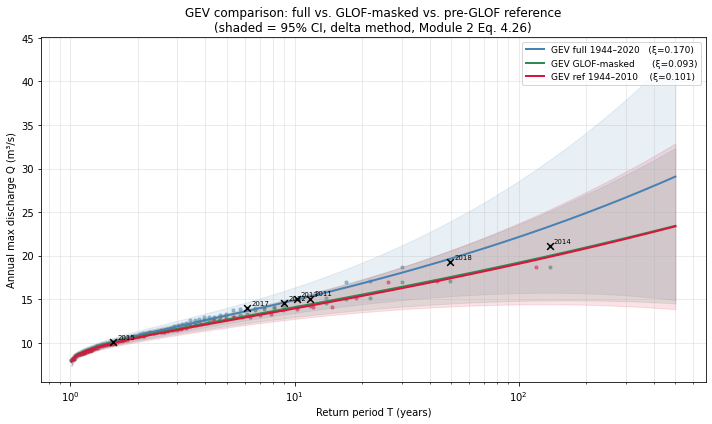

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

curves = [
    (q_f, lo_f, hi_f, Tf_e, Qf_s, 'steelblue', f'GEV full 1944–2020   (ξ={xi_f:.3f})'),
    (q_c, lo_c, hi_c, Tc_e, Qc_s, 'seagreen',  f'GEV GLOF-masked      (ξ={xi_c:.3f})'),
    (q_r, lo_r, hi_r, Tr_e, Qr_s, 'crimson',   f'GEV ref 1944–2010    (ξ={xi_r:.3f})'),
]
for q, lo, hi, T_emp, Q_emp, color, label in curves:
    ax.scatter(T_emp, Q_emp, s=10, color=color, alpha=0.45)
    ax.semilogx(T_plot, q, color=color, lw=2, label=label)
    ax.fill_between(T_plot, lo, hi, color=color, alpha=0.12)

# Highlight GLOF-year annual maxima
n_f = len(Q_full)
for yr, dt in GLOF_DATES.items():
    if yr in Q_full.index:
        qv  = Q_full[yr]
        idx = np.searchsorted(Qf_s, qv)
        te  = Tf_e[min(idx, n_f - 1)]
        ax.scatter(te, qv, color='black', zorder=6, s=45, marker='x')
        ax.annotate(str(yr), (te, qv), xytext=(4, 3),
                    textcoords='offset points', fontsize=7)

ax.set_xlabel('Return period T (years)')
ax.set_ylabel('Annual max discharge Q (m³/s)')
ax.set_title(
    'GEV comparison: full vs. GLOF-masked vs. pre-GLOF reference\n'
    '(shaded = 95% CI, delta method, Module 2 Eq. 4.26)'
)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / '02_gev_three_curves.png', dpi=150)
plt.show()

## 6 — Design Quantile Comparison Table (Module 2, Eq. 4.22)

Quantifies how much GLOFs inflate engineering design floods.

In [7]:
T_des = [2, 5, 10, 20, 50, 100, 200]

print(f'{"T (yr)":>7}  {"Q_full":>8}  {"CI_full":>14}  '
      f'{"Q_masked":>9}  {"CI_masked":>14}  {"Q_ref":>7}  {"Δ full→masked":>14}')
print('-' * 90)
for T in T_des:
    i = np.argmin(np.abs(T_plot - T))
    delta = 100 * (q_c[i] - q_f[i]) / q_f[i]
    print(
        f'{T:>7}  {q_f[i]:>8.2f}  [{lo_f[i]:>5.2f},{hi_f[i]:>6.2f}]  '
        f'{q_c[i]:>9.2f}  [{lo_c[i]:>5.2f},{hi_c[i]:>6.2f}]  '
        f'{q_r[i]:>7.2f}  {delta:>+13.1f}%'
    )

 T (yr)    Q_full         CI_full   Q_masked       CI_masked    Q_ref   Δ full→masked
------------------------------------------------------------------------------------------
      2     10.86  [10.34, 11.39]      10.73  [10.25, 11.20]    10.62           -1.3%
      5     13.13  [12.23, 14.03]      12.67  [11.93, 13.41]    12.53           -3.5%
     10     14.87  [13.43, 16.32]      14.07  [12.95, 15.19]    13.91           -5.4%
     20     16.83  [14.43, 19.22]      15.54  [13.77, 17.32]    15.38           -7.6%
     50     19.68  [15.35, 24.00]      17.57  [14.51, 20.62]    17.41          -10.7%
    100     22.11  [15.70, 28.51]      19.19  [14.81, 23.56]    19.04          -13.2%
    200     24.91  [15.68, 34.15]      20.96  [14.87, 27.05]    20.84          -15.9%


## 7 — AIC Model Comparison (Module 2, §5.5.2, Eq. 5.12)

AIC = 2k − 2 ln(L̂). Both GEV fits have k = 3. Note: direct comparison is only valid for same-size datasets.

In [8]:
for label, data, xi, mu, sigma in [
    ('Full 1944–2020', Q_full.values,  xi_f, mu_f, sigma_f),
    ('GLOF-masked',    Q_clean.values, xi_c, mu_c, sigma_c),
    ('Ref 1944–2010',  Q_ref.values,   xi_r, mu_r, sigma_r),
]:
    print(f'{label:<22}: AIC = {gev_aic(data, xi, mu, sigma):.2f}  (n={len(data)})')

Full 1944–2020        : AIC = 346.93  (n=77)
GLOF-masked           : AIC = 328.16  (n=77)
Ref 1944–2010         : AIC = 283.54  (n=67)


## 8 — Return Period Comparison: Full vs. GLOF-Masked

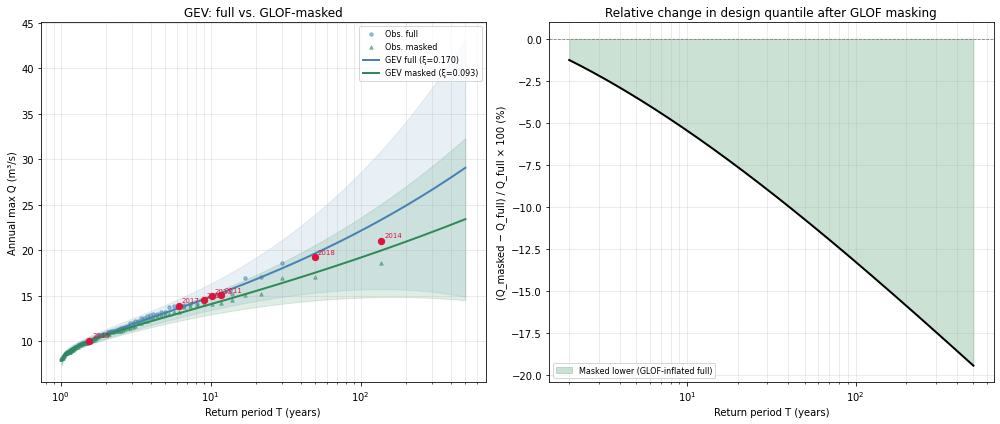

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(Tf_e, Qf_s, s=12, color='steelblue', alpha=0.5, label='Obs. full')
ax.scatter(Tc_e, Qc_s, s=12, marker='^', color='seagreen', alpha=0.5, label='Obs. masked')
ax.semilogx(T_plot, q_f, 'steelblue', lw=2, label=f'GEV full (ξ={xi_f:.3f})')
ax.semilogx(T_plot, q_c, 'seagreen',  lw=2, label=f'GEV masked (ξ={xi_c:.3f})')
ax.fill_between(T_plot, lo_f, hi_f, color='steelblue', alpha=0.12)
ax.fill_between(T_plot, lo_c, hi_c, color='seagreen',  alpha=0.15)
for yr, dt in GLOF_DATES.items():
    if yr in Q_full.index:
        qv  = Q_full[yr]
        idx = np.searchsorted(Qf_s, qv)
        te  = Tf_e[min(idx, len(Qf_s) - 1)]
        ax.scatter(te, qv, color='crimson', zorder=5, s=40)
        ax.annotate(str(yr), (te, qv), xytext=(3, 3),
                    textcoords='offset points', fontsize=7, color='crimson')
ax.set_xlabel('Return period T (years)')
ax.set_ylabel('Annual max Q (m³/s)')
ax.set_title('GEV: full vs. GLOF-masked')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1]
diff_pct = 100 * (q_c - q_f) / q_f
mask = T_plot >= 2
ax2.semilogx(T_plot[mask], diff_pct[mask], 'k-', lw=2)
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.fill_between(T_plot[mask], diff_pct[mask], 0,
                 where=diff_pct[mask] < 0, color='seagreen', alpha=0.25,
                 label='Masked lower (GLOF-inflated full)')
ax2.set_xlabel('Return period T (years)')
ax2.set_ylabel('(Q_masked − Q_full) / Q_full × 100 (%)')
ax2.set_title('Relative change in design quantile after GLOF masking')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / '02_gev_comparison.png', dpi=150)
plt.show()